# Лабораторная работа №3


### Загрузка датасета

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import missingno as msn

In [4]:
import pandas as pd

train = pd.read_csv("/Users/danilaskiba/git_repository/Machine-Learning/Practicum/Lab3/train.csv")
test = pd.read_csv("/Users/danilaskiba/git_repository/Machine-Learning/Practicum/Lab3/test.csv")

nrmse_train = train.copy()

## Кодировка категориальных переменных

In [5]:
train['Тип Вектора Мощи'].unique()

array(['Выше среднего', 'Слабый', 'Сильный', 'Ниже среднего'],
      dtype=object)

Есть отношение порядка, применим Label кодировщик

In [ ]:
# from sklearn.preprocessing import LabelEncoder

# lable_encod = LabelEncoder()

# train["Тип Вектора Мощи"] = lable_encod.fit_transform(train['Тип Вектора Мощи'])


mapping = {'Ниже среднего': 1, 'Слабый': 0, 'Сильный': 3, 'Выше среднего': 2}
train["Тип Вектора Мощи"] = train["Тип Вектора Мощи"].map(mapping)

In [7]:
test["Тип Вектора Мощи"] = test['Тип Вектора Мощи'].map(mapping)

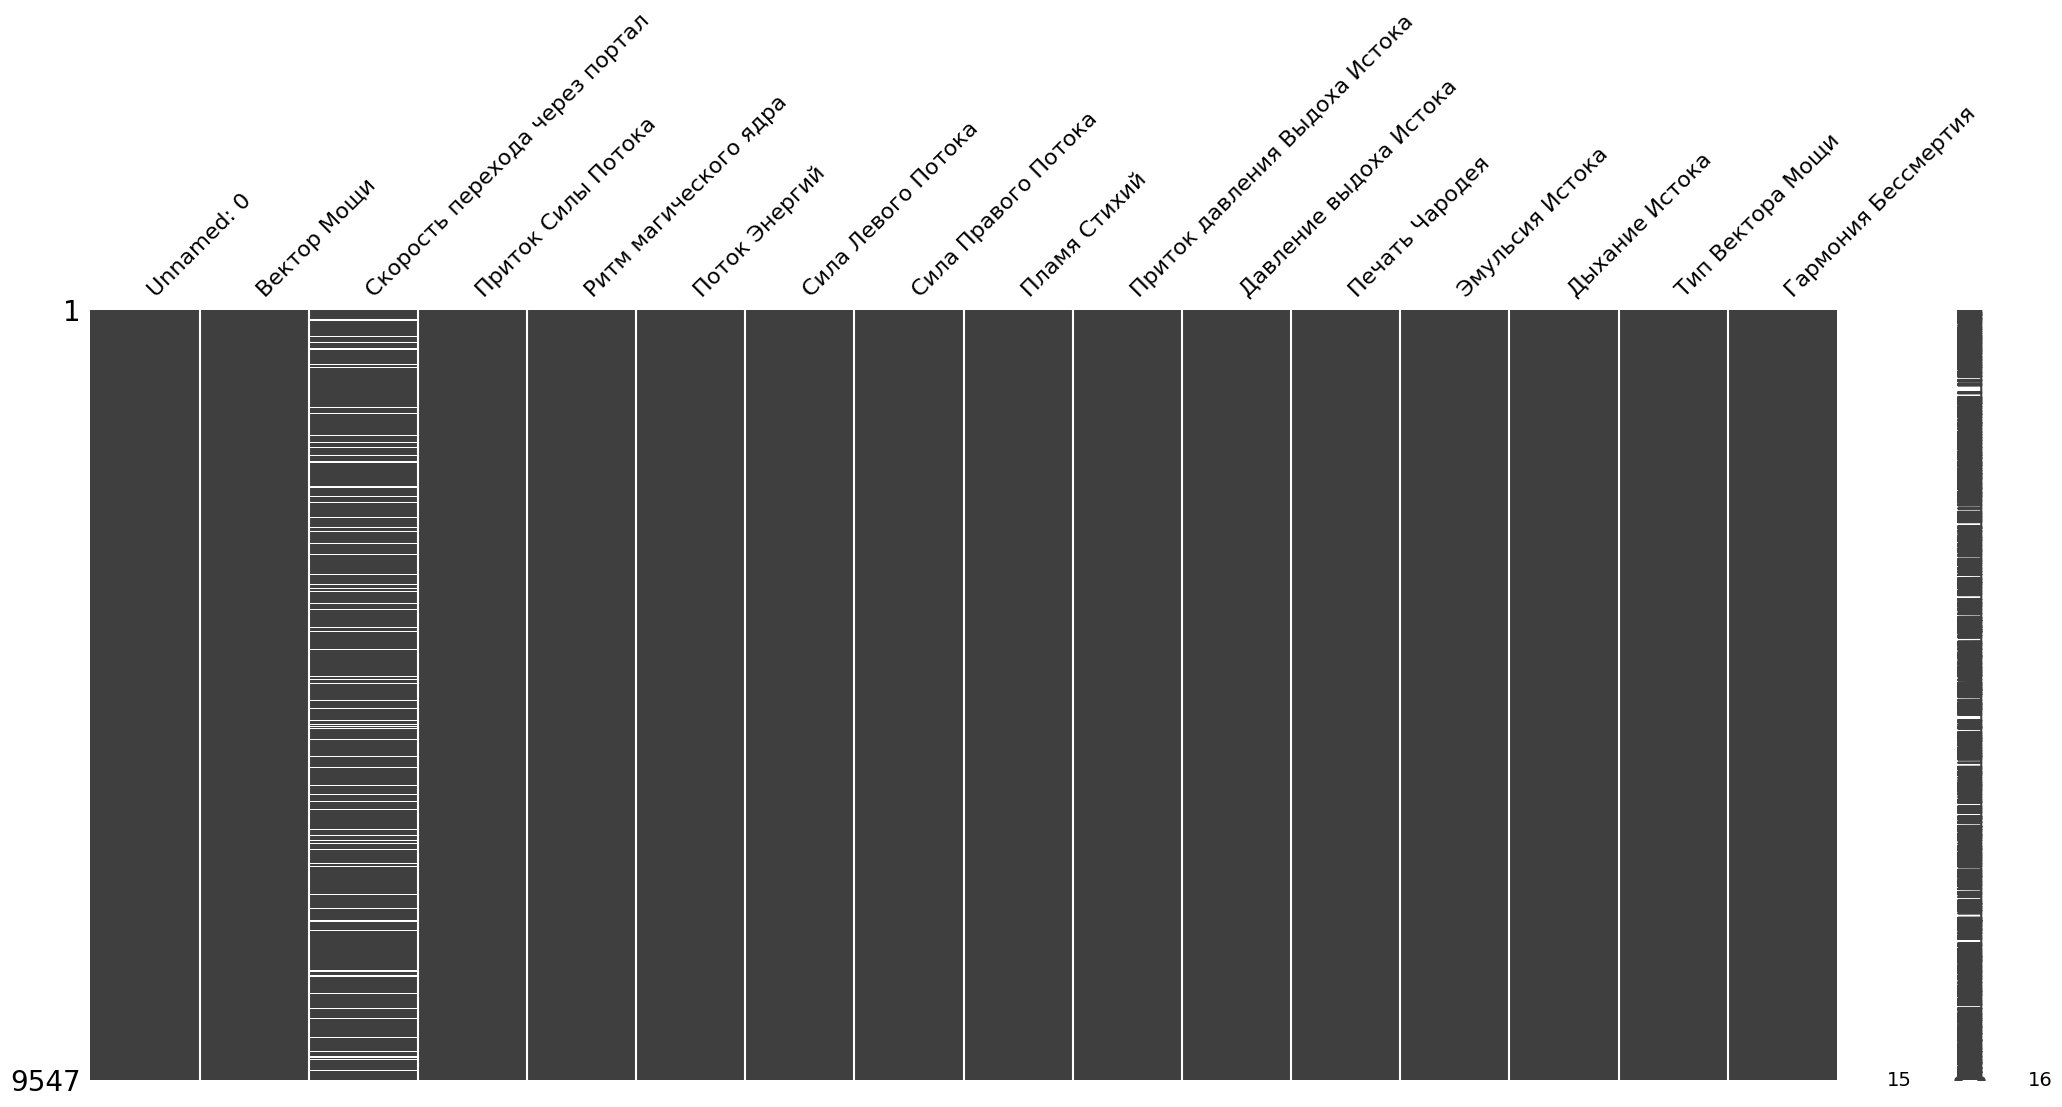

In [8]:
msn.matrix(train);

In [9]:
nrmse_train = train.dropna().drop(columns=['Unnamed: 0'])

### Заполнение пропущенных значений

#### Статистический метод

Признак вещественный, значит попробуем заполнить следующими статистиками:
- Медиана
- Среднее
- Мода

In [10]:
#KL - дивергенция
from scipy.special import rel_entr
def kl_divergence(p, q):
    hist_p, bin_edges = np.histogram(p, bins = 20, density=True)
    hist_q, _ = np.histogram(q, bins=bin_edges,density=True )

    hist_p /= np.sum(hist_p)
    hist_q /= np.sum(hist_q)
    return np.sum(rel_entr(hist_p, hist_q))

In [11]:
import matplotlib.pyplot as plt
def fill_gap(data : pd.DataFrame, stats : float, name_feat : str = 'Скорость перехода через портал'):

    p = data[name_feat].dropna()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

    ax1.hist(p, bins = 20)
    ax1.set_title("До заполнения пропусков")

    q = data[name_feat].fillna(stats)

    ax2.hist(q, bins = 20)
    ax2.set_title("После заполнения пропусков")

    plt.tight_layout()
    plt.show()

    print(f"KL - дивергенция {kl_divergence(p, q)}")

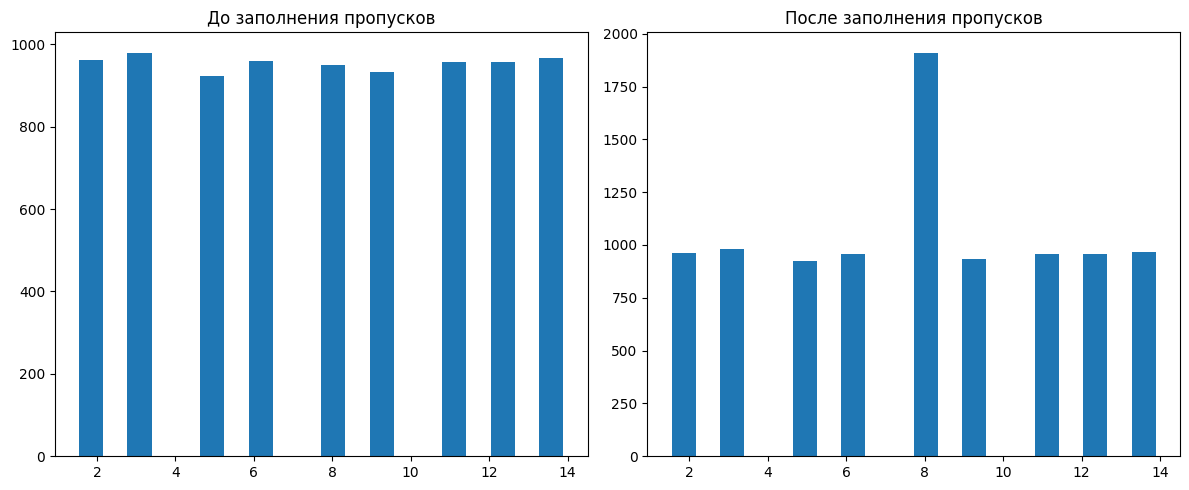

KL - дивергенция 0.02876183503190572


In [12]:
#Медиана 
fill_gap(train, train['Скорость перехода через портал'].median())

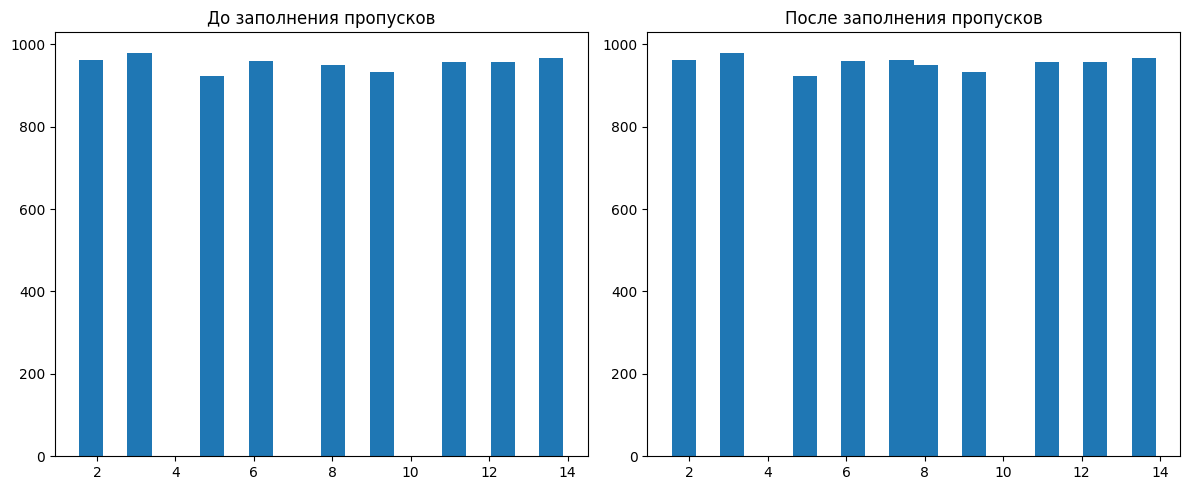

KL - дивергенция 0.10609399921352716


In [13]:
#Среднее
fill_gap(train, train['Скорость перехода через портал'].mean())

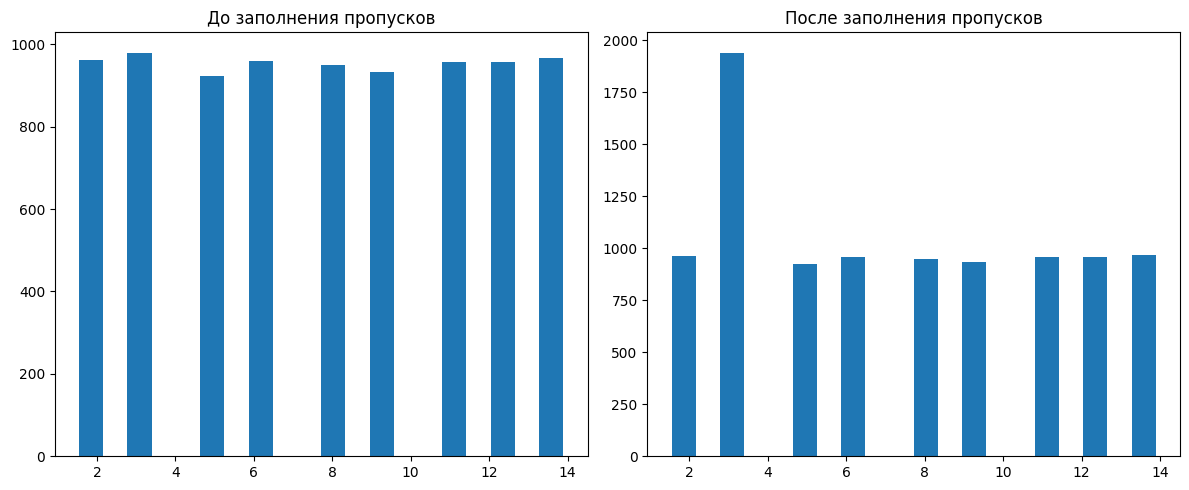

KL - дивергенция 0.028090517816566428


In [246]:
#Мода
fill_gap(train, train['Скорость перехода через портал'].mode().values[0])

Лучшей статистикой для заполнения пропусков данного столбца является **мода**

### Машинный метод

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import GradientBoostingRegressor

In [15]:
def fill_ml(data : pd.DataFrame, model, name_feat : str = 'Скорость перехода через портал'):
    
    p = data[name_feat].dropna()

    fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

    ax1.hist(p, bins = 20)
    ax1.set_title("До заполнения пропусков")

    q = pd.DataFrame(model.fit_transform(data), columns=data.columns)[name_feat]

    ax2.hist(q, bins = 20)
    ax2.set_title("После заполнения")

    print(f"KL - дивергенция {kl_divergence(p, q)}")

#### IterativeImputer

In [16]:
iter_imp = IterativeImputer(
    max_iter=10, 
    random_state=50,
    estimator= GradientBoostingRegressor(n_estimators=100, random_state=42)
)

KL - дивергенция 0.012696562662431111


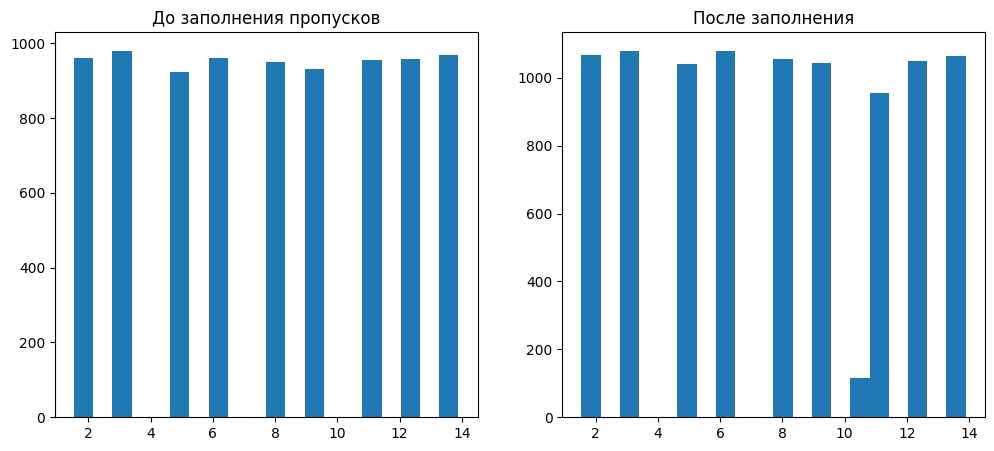

In [250]:
fill_ml(train, iter_imp)

##### KNNImputer

In [20]:
knn_imputer = KNNImputer(
    n_neighbors=5,         
    weights='uniform',     
    metric='nan_euclidean' 
)

KL - дивергенция 0.005381334665028324


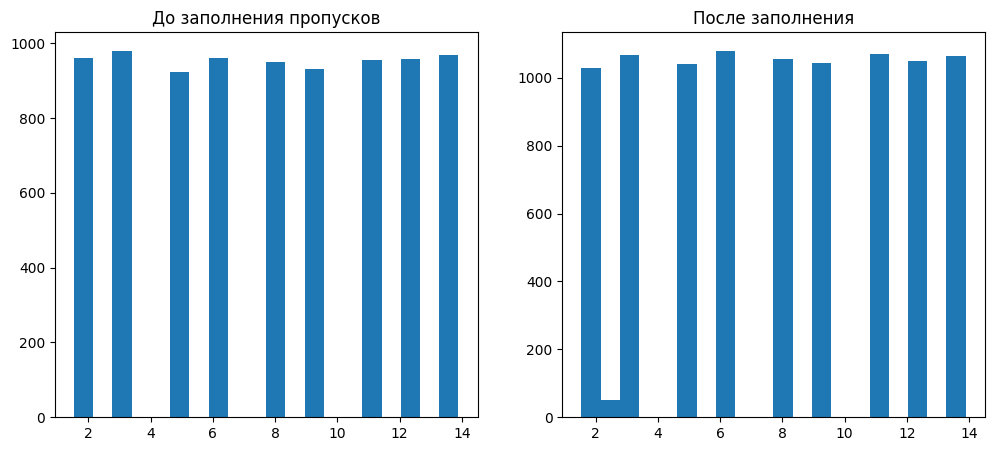

In [21]:
fill_ml(train, knn_imputer)

Лучшие результаты из машинных методов показал **KNNImputer**

#### Вывод
Лучшую метрику показал машинный метод с заполнением пропусков **KNNImputer**, остановимся на нём

In [22]:
name_feat = 'Скорость перехода через портал'

In [23]:
columns = train.columns
train = pd.DataFrame(knn_imputer.transform(train), columns=columns).drop(columns=['Unnamed: 0'])

In [24]:
train.to_csv('/Users/danilaskiba/git_repository/Machine-Learning/Practicum/Lab4/train.csv')

<Axes: >

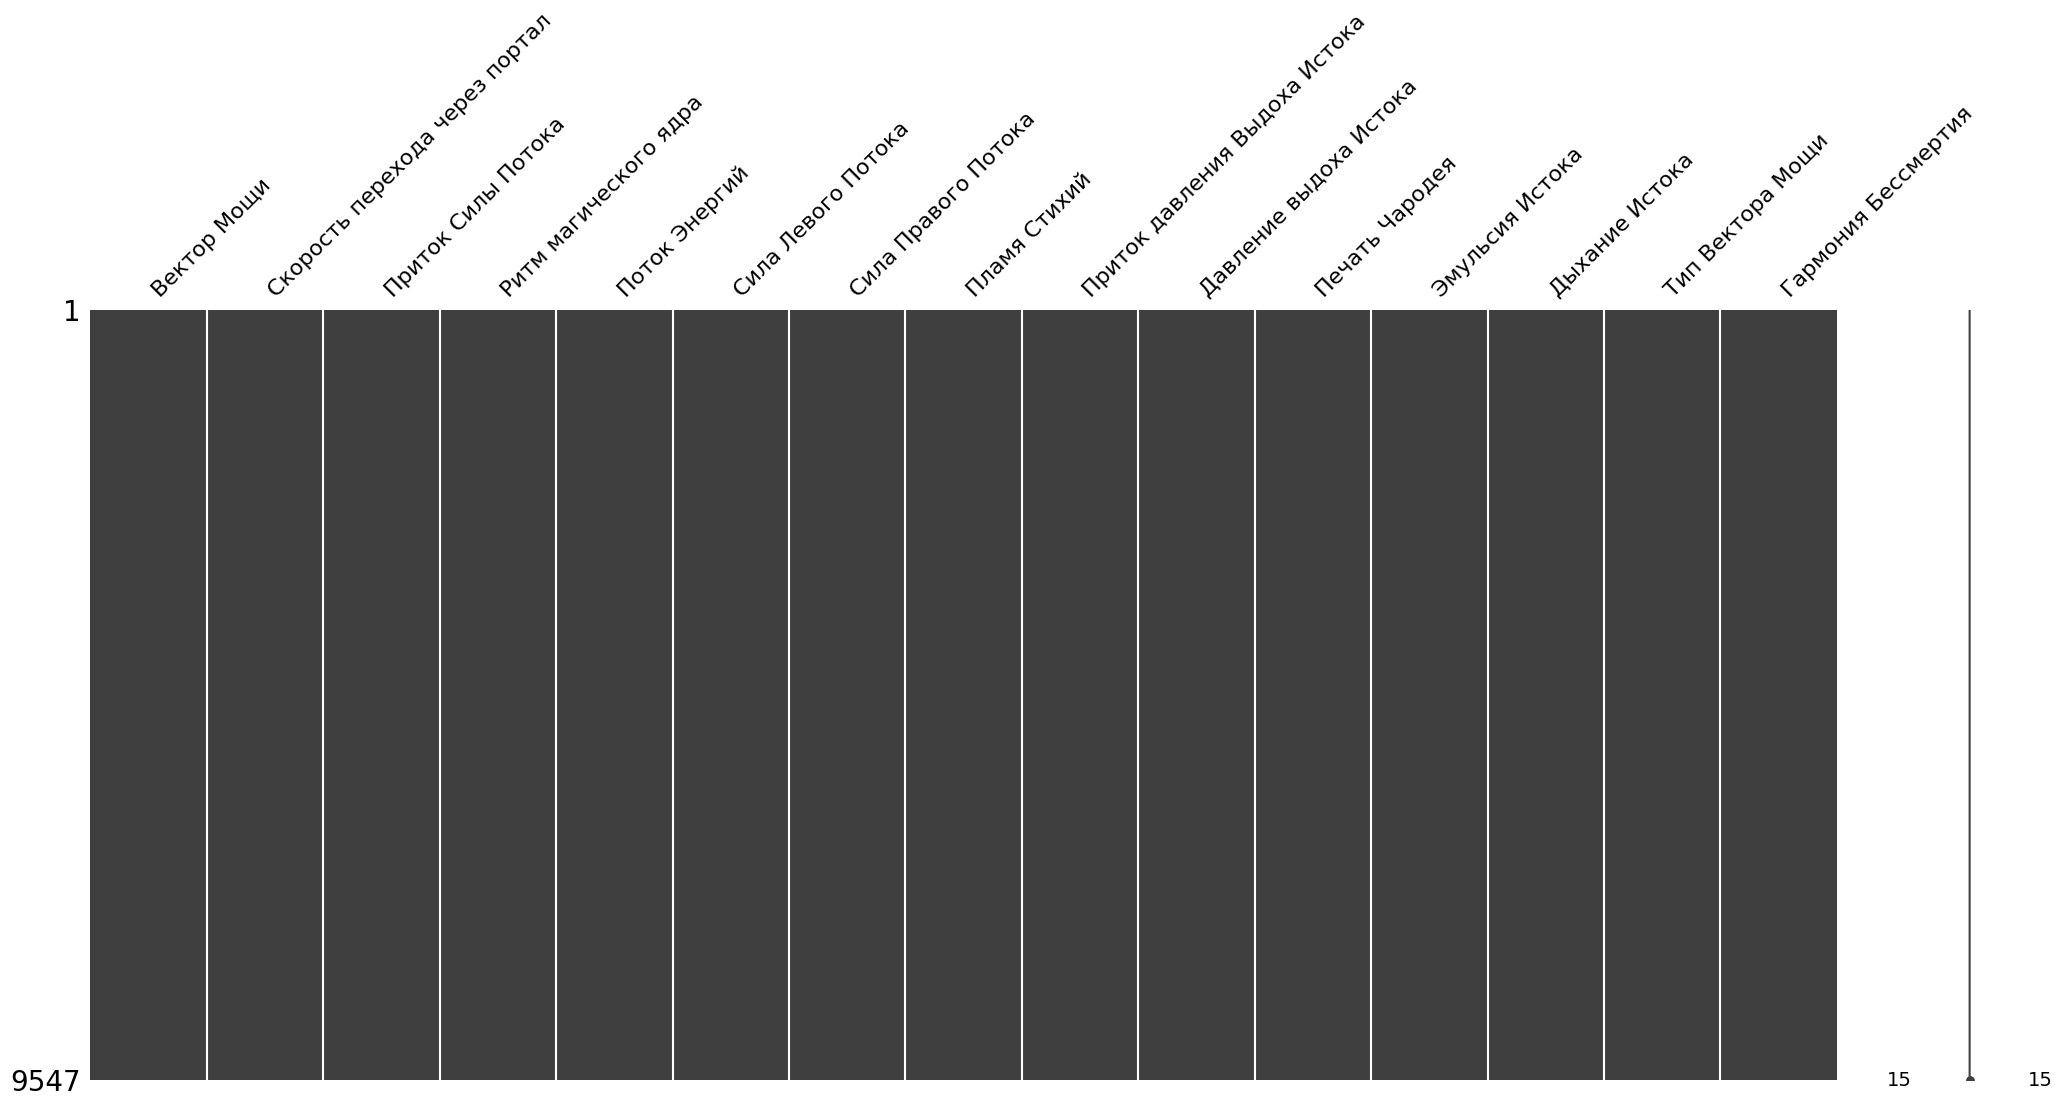

In [255]:
msn.matrix(train)

### Кодирование тесовой выборки

In [25]:
test[name_feat] = test[name_feat].map(mapping)

In [26]:
test = pd.DataFrame(knn_imputer.transform(test), columns=columns).drop(columns=['Unnamed: 0'])

In [27]:
test.to_csv('/Users/danilaskiba/git_repository/Machine-Learning/Practicum/Lab4/test.csv')

### Заполнение пропусков

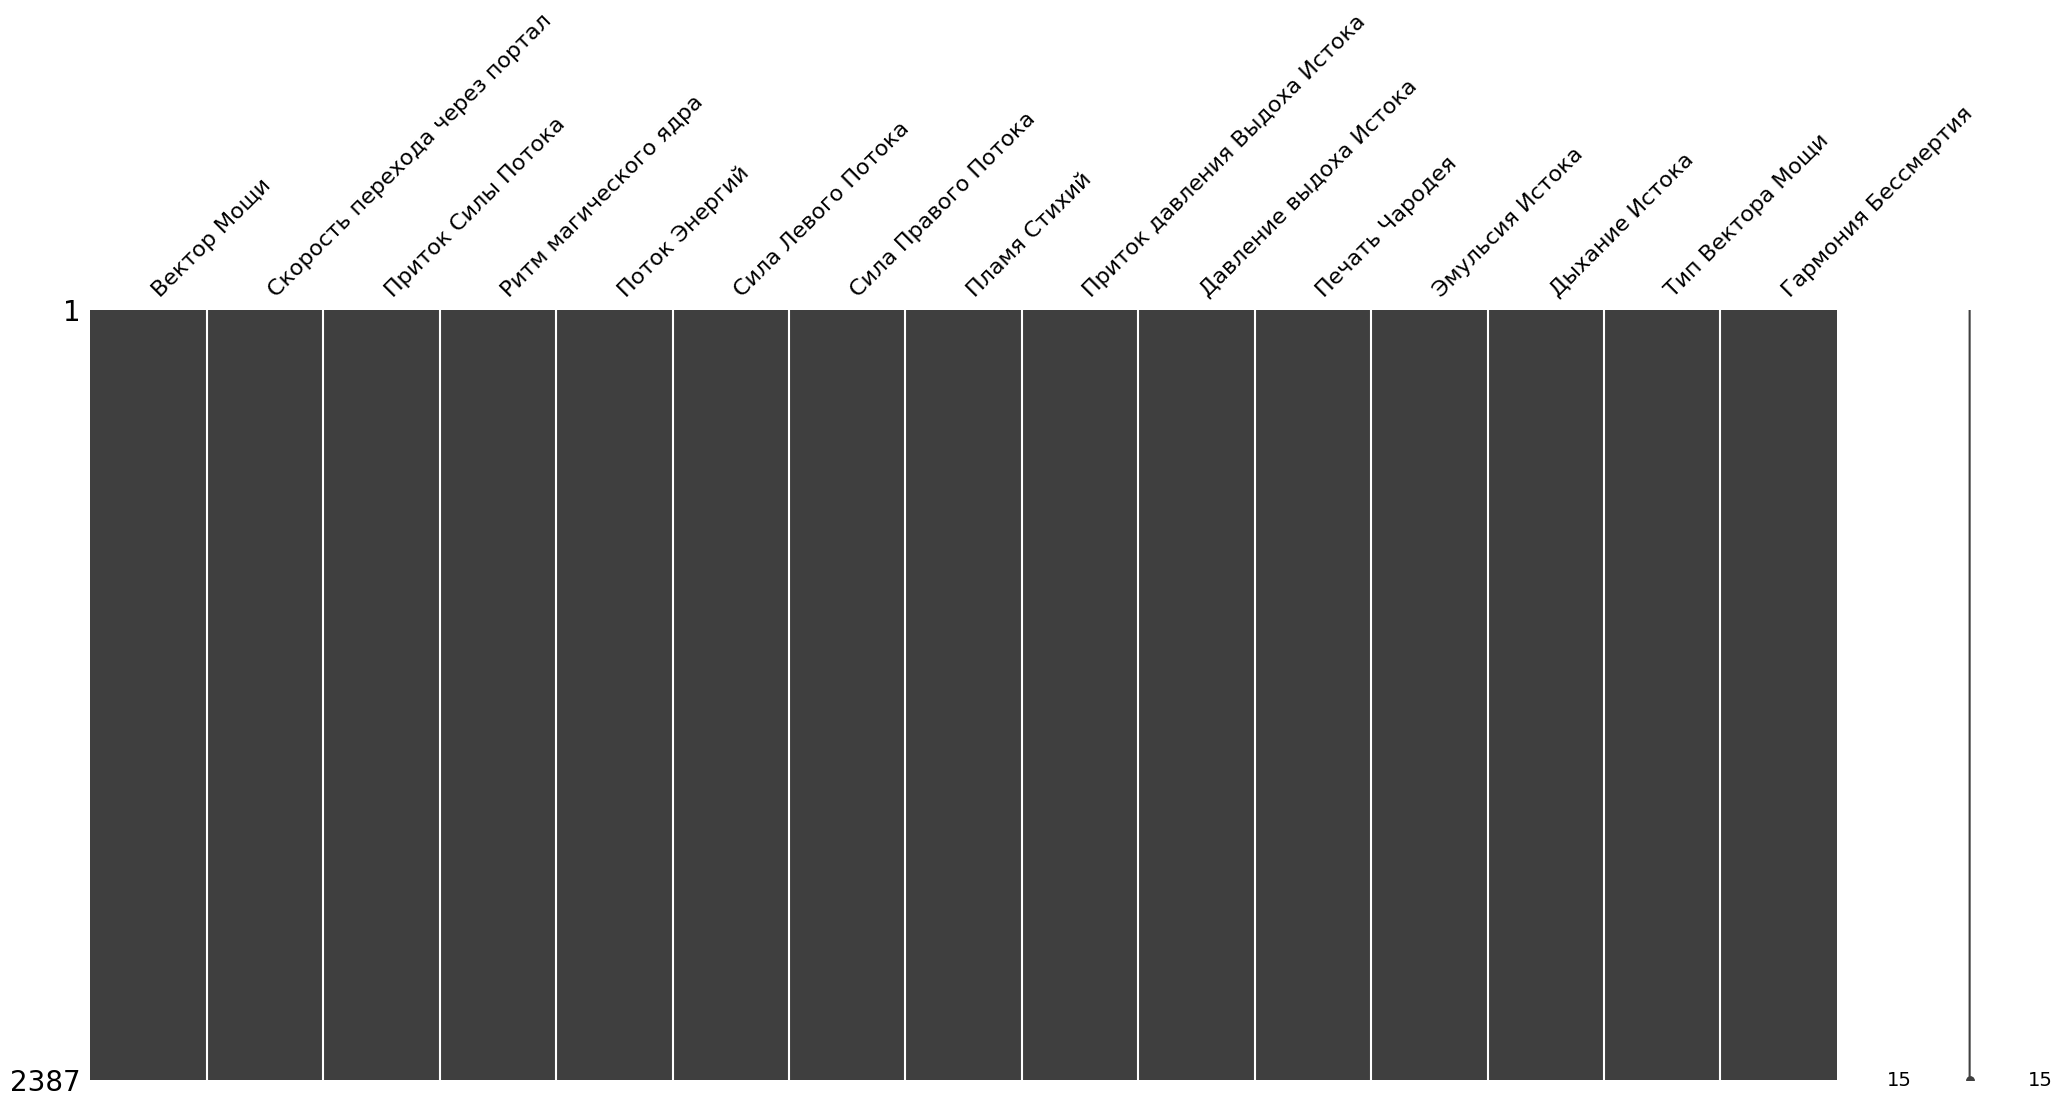

In [258]:
msn.matrix(test);

## Доп задание

**NRMSE** (Normalized Root Mean Square Error)  - нормализивонная среднеквадратичное отклонение
- Показывает величину ошибки заполнения пропусков 
- Показывает относительную величину ошибки (в сравнении с RMSE)

Создание маски

In [259]:
nrmse_train = nrmse_train.reset_index(drop=True)

In [260]:
nrmse_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
0,1.138,1.54332,2706.698,138.966361,6622.351,6.270,6.270,545.800,1.184,6.450,26.222,0.194,0.975,0,0.979
1,7.148,10.80324,38998.248,280.444531,9120.644,332.275,332.275,835.034,2.980,15.730,44.789,0.887,0.976,3,0.977
2,1.138,1.54332,6763.006,144.782287,6697.636,9.375,9.375,620.925,1.322,7.078,0.000,0.278,0.982,0,1.000
3,8.206,12.34656,50994.067,323.324443,9319.460,438.106,438.106,917.854,3.566,18.180,59.577,1.179,0.964,3,0.999
4,5.140,7.71660,21630.599,201.513796,8479.072,175.272,175.272,715.290,2.084,11.171,25.585,0.506,0.971,2,0.980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8581,2.088,3.08664,3598.386,145.007435,6812.997,29.668,29.668,515.378,1.229,6.605,0.000,0.143,0.974,0,0.988
8582,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.018,3.607,18.693,60.083,1.189,0.998,3,0.980
8583,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.160,3.589,18.621,61.190,1.211,0.972,3,0.979
8584,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.989,2.497,13.129,34.453,0.682,0.953,2,0.992


In [261]:
mask = pd.DataFrame(False, index=nrmse_train.index, columns=nrmse_train.columns)
masked_df = nrmse_train.copy()


for col in masked_df.columns:
    n = int(len(nrmse_train)*0.1)
    missing_index = np.random.choice(nrmse_train.index, n, replace=False)

    masked_df.loc[missing_index, col] = np.nan
    mask.loc[missing_index, col] = True



### Обучениие модели

In [ ]:
knnImp = KNNImputer(
    n_neighbors=5,         
    weights='uniform',     
    metric='nan_euclidean' 
)


fill_nrmse_train = pd.DataFrame(knnImp.fit_transform(masked_df), columns=masked_df.columns).reset_index(drop=True)

In [263]:
fill_nrmse_train

,Вектор Мощи,Скорость перехода через портал,Приток Силы Потока,Ритм магического ядра,Поток Энергий,Сила Левого Потока,Сила Правого Потока,Пламя Стихий,Приток давления Выдоха Истока,Давление выдоха Истока,Печать Чародея,Эмульсия Истока,Дыхание Истока,Тип Вектора Мощи,Гармония Бессмертия
0,1.138,1.54332,2706.698,138.966361,6622.351,6.270,6.270,545.8000,1.1840,6.4500,26.2220,0.1940,0.9750,0.0,0.979
1,7.148,10.80324,38998.248,280.444594,9120.644,332.275,332.275,835.0340,2.9800,15.7300,44.7890,0.8818,0.9760,3.0,0.977
2,1.138,1.54332,6763.006,144.782287,6697.636,9.375,9.375,514.2778,1.3220,7.0780,0.0000,0.2780,0.9672,0.0,1.000
3,8.206,12.34656,50994.067,323.324443,9319.460,438.106,438.106,917.8540,3.5660,18.1800,59.5770,1.1790,0.9640,3.0,0.999
4,5.140,7.71660,21630.599,201.513796,8479.072,175.272,175.272,715.2900,2.0840,11.0546,24.5354,0.5060,0.9710,2.0,0.980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8581,2.088,3.08664,3598.386,145.007435,6806.306,29.668,29.668,515.3780,1.2290,6.6050,0.0000,0.1430,0.9740,0.0,0.988
8582,8.206,12.34656,50989.676,323.300567,9292.800,437.925,437.925,915.0180,3.6022,18.6930,60.0830,1.1890,0.9980,3.0,0.980
8583,8.206,12.34656,50993.686,323.319312,9306.729,438.021,438.021,933.1600,3.5890,18.6210,61.1900,1.2110,0.9720,3.0,0.979
8584,6.175,9.25992,29797.053,241.615179,8842.649,246.362,246.362,779.9890,2.4970,13.1290,34.3560,0.6818,0.9530,2.0,0.992


#### Метрики

In [264]:
from sklearn.metrics import root_mean_squared_error

nrmse = {}

for col in nrmse_train.columns:
    col_mask = mask[col]
    if col_mask.any():
        original_vals = nrmse_train.loc[col_mask,col]
        imputed_vals = fill_nrmse_train.loc[col_mask, col]

        rmse= root_mean_squared_error(original_vals, imputed_vals)

        value_range = original_vals.max() - original_vals.min()
        nrmse_col = rmse/value_range if value_range != 0 else rmse

        nrmse[col] = nrmse_col
    

for col in nrmse:
    print(f"{col}: NRMSE = {nrmse[col]:.2f}")


Вектор Мощи: NRMSE = 0.01
Скорость перехода через портал: NRMSE = 0.01
Приток Силы Потока: NRMSE = 0.01
Ритм магического ядра: NRMSE = 0.01
Поток Энергий: NRMSE = 0.01
Сила Левого Потока: NRMSE = 0.01
Сила Правого Потока: NRMSE = 0.01
Пламя Стихий: NRMSE = 0.03
Приток давления Выдоха Истока: NRMSE = 0.00
Давление выдоха Истока: NRMSE = 0.01
Печать Чародея: NRMSE = 0.04
Эмульсия Истока: NRMSE = 0.01
Дыхание Истока: NRMSE = 0.15
Тип Вектора Мощи: NRMSE = 0.01
Гармония Бессмертия: NRMSE = 0.19
